# Experiment 5.5.2 — Progress-Anchored History-Residual Routing

**Analysis-only.** Reads finalized artifacts only; no training, alpha selection, Slurm submission, or regeneration. Coordinate → Reset → Lag1 → Ordered separates flexible progress mapping, current WHAT, previous WHAT, and accumulated history.


In [1]:
from pathlib import Path
import json, math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_repo_root(start: Path | None = None) -> Path:
    here=(start or Path.cwd()).resolve()
    for candidate in (here,*here.parents):
        if (candidate/"AGENTS.md").is_file() and (candidate/"scripts").is_dir(): return candidate
    raise FileNotFoundError("Could not find writingRing repository root")
REPO_ROOT=find_repo_root()
ARTIFACT_ROOT=REPO_ROOT/"notebooks"/"artifacts"/"experiment_5_5_2_progress_anchored_history_residual"/"progress_anchored_history_residual_v1"
FILES={"selection":"selection.json","screen":"screen_summary.csv","screen_paired":"screen_paired_deltas.csv","final":"final_summary.csv","paired":"final_paired_deltas.csv","diagnostics":"residual_diagnostics.csv","alignment":"residual_alignment.csv","probes":"residual_only_probes.csv","gaps":"generalization_gap.csv","clock_progress":"clock_progress_alignment.csv","same_what":"same_what_same_coordinate.csv","manifest":"manifest.json"}
paths={k:ARTIFACT_ROOT/v for k,v in FILES.items()}
missing=[str(p) for p in paths.values() if not p.is_file()]
if missing: raise FileNotFoundError("Exp5.5.2 finalized artifacts are incomplete:\n"+"\n".join(missing))
selection=json.loads(paths["selection"].read_text()); manifest=json.loads(paths["manifest"].read_text())
screen=pd.read_csv(paths["screen"]); screen_paired=pd.read_csv(paths["screen_paired"]); final=pd.read_csv(paths["final"]); paired=pd.read_csv(paths["paired"])
diagnostics=pd.read_csv(paths["diagnostics"]); alignment=pd.read_csv(paths["alignment"]); probes=pd.read_csv(paths["probes"])
gaps=pd.read_csv(paths["gaps"]); clock_progress=pd.read_csv(paths["clock_progress"]); same_what=pd.read_csv(paths["same_what"])
selection


{'clock_residual_rescue_supported_by_mode': {'coordinate': True,
  'lag1': True,
  'ordered': True,
  'reset': True},
 'eligibility_rule': 'per mode: mean paired Clock-val BA delta > 0 and >=4/5 seed deltas nonnegative',
 'experiment_id': 'experiment_5_5_2_progress_anchored_history_residual',
 'oracle_used_for_alpha_selection': False,
 'protocol_version': 'progress_anchored_history_residual_v1',
 'screen_paired_deltas': 'notebooks/artifacts/experiment_5_5_2_progress_anchored_history_residual/progress_anchored_history_residual_v1/screen_paired_deltas.csv',
 'screen_runs': 'notebooks/artifacts/experiment_5_5_2_progress_anchored_history_residual/progress_anchored_history_residual_v1/screen_runs.csv',
 'screen_summary': 'notebooks/artifacts/experiment_5_5_2_progress_anchored_history_residual/progress_anchored_history_residual_v1/screen_summary.csv',
 'selected_alpha_by_mode': {'coordinate': 0.25,
  'lag1': 0.25,
  'ordered': 0.25,
  'reset': 0.25},
 'selection_rule': 'per mode: among eligi

## Selection and final performance

Each residual mode owns its Clock-validation-selected alpha. Oracle and test are excluded from selection.


,residual_mode,alpha,mean_val_balanced_accuracy,sd_val_balanced_accuracy,sem_val_balanced_accuracy,mean_delta_vs_clock,nonnegative_seed_count,eligible
0,coordinate,0.25,0.576679,0.030146,0.013482,0.001515,5,True
1,coordinate,0.50,0.576679,0.030146,0.013482,0.001515,5,True
2,coordinate,1.00,0.576552,0.030070,0.013448,0.001389,5,True
6,lag1,0.25,0.576805,0.030072,0.013449,0.001641,5,True
7,lag1,0.50,0.576805,0.030072,0.013449,0.001641,5,True
8,lag1,1.00,0.575416,0.028280,0.012647,0.000253,5,True
9,ordered,0.25,0.576679,0.030146,0.013482,0.001515,5,True
10,ordered,0.50,0.578472,0.031294,0.013995,0.003308,5,True
11,ordered,1.00,0.576552,0.030070,0.013448,0.001389,5,True
3,reset,0.25,0.576805,0.030072,0.013449,0.001641,5,True


,condition,n_runs,mean_test_balanced_accuracy,sd_test_balanced_accuracy,sem_test_balanced_accuracy,mean_test_accuracy,mean_test_macro_f1
2,fixed250,5,0.595230,0.009826,0.004394,0.608219,0.595250
1,oracle_progress,5,0.571931,0.036235,0.016205,0.582192,0.568902
11,oracle_progress+ordered,5,0.571931,0.036235,0.016205,0.582192,0.568663
10,oracle_progress+lag1,5,0.571931,0.036235,0.016205,0.582192,0.568845
9,oracle_progress+reset,5,0.570741,0.036748,0.016434,0.580822,0.567560
8,oracle_progress+coordinate,5,0.569352,0.034428,0.015397,0.579452,0.565994
7,clock+ordered,5,0.552455,0.038302,0.017129,0.560274,0.540197
6,clock+lag1,5,0.551119,0.040188,0.017973,0.557534,0.539614
0,clock,5,0.550074,0.037300,0.016681,0.557534,0.538569
4,clock+coordinate,5,0.548884,0.037076,0.016581,0.556164,0.537511


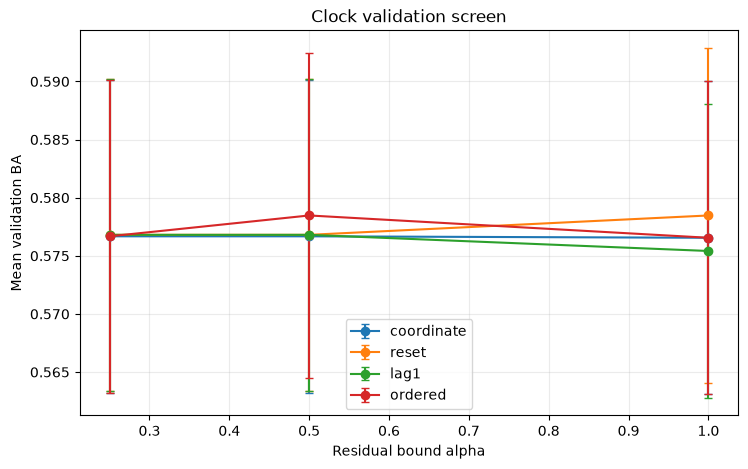

In [2]:
display(screen.sort_values(["residual_mode","alpha"])); display(final.sort_values("mean_test_balanced_accuracy",ascending=False))
fig,ax=plt.subplots(figsize=(8.5,5))
for mode,g in screen.groupby("residual_mode",sort=False):
    g=g.sort_values("alpha"); ax.errorbar(g["alpha"],g["mean_val_balanced_accuracy"],yerr=g["sem_val_balanced_accuracy"],marker="o",capsize=3,label=mode)
ax.set(xlabel="Residual bound alpha",ylabel="Mean validation BA",title="Clock validation screen"); ax.legend(); ax.grid(True,alpha=.25); plt.show()


## Paired mechanistic contrasts

Primary contrasts: Ordered−Anchor, Ordered−Reset, Ordered−Coordinate, Ordered−Lag1, and alignment ablations.


,anchor,comparison,mean,sem
0,clock,coordinate_minus_anchor,-0.001190,0.001190
2,clock,lag1_minus_anchor,0.001044,0.002882
3,clock,ordered_minus_anchor,0.002381,0.002381
7,clock,ordered_minus_circular_shift,0.000476,0.000476
5,clock,ordered_minus_coordinate,0.003571,0.003571
6,clock,ordered_minus_lag1,0.001337,0.003901
8,clock,ordered_minus_random_shuffle,0.000000,0.000000
4,clock,ordered_minus_reset,0.006098,0.005035
1,clock,reset_minus_anchor,-0.003718,0.004910
9,oracle_progress,coordinate_minus_anchor,-0.002579,0.001587


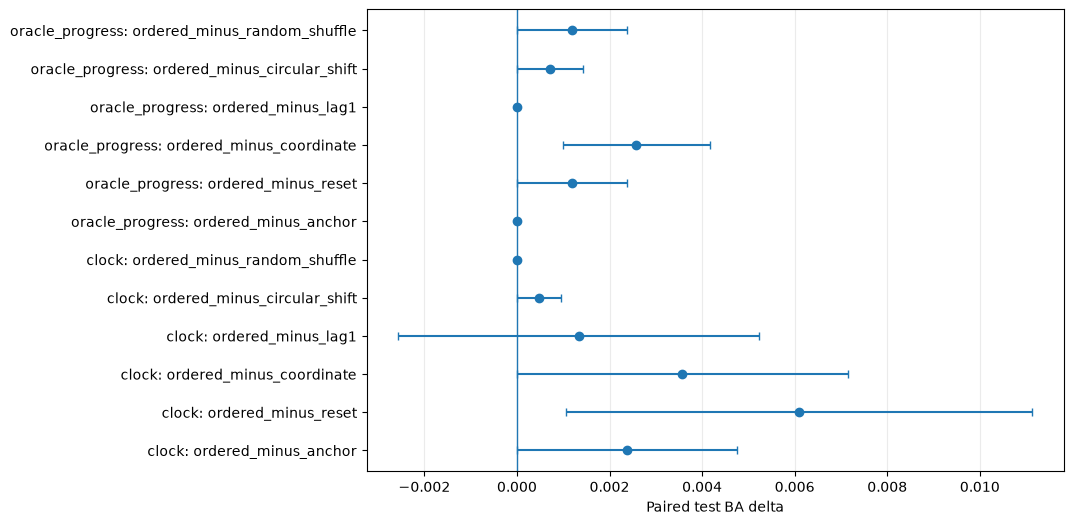

In [3]:
def mean_sem(df,value,groups):
    rows=[]
    for keys,g in df.groupby(groups,sort=False):
        if not isinstance(keys,tuple): keys=(keys,)
        x=g[value].to_numpy(float); row=dict(zip(groups,keys)); row["mean"]=x.mean(); row["sem"]=0.0 if len(x)<2 else x.std(ddof=1)/math.sqrt(len(x)); rows.append(row)
    return pd.DataFrame(rows)
contrast=mean_sem(paired,"delta_test_balanced_accuracy",["anchor","comparison"]); display(contrast.sort_values(["anchor","comparison"]))
focus=contrast[contrast["comparison"].isin(["ordered_minus_anchor","ordered_minus_reset","ordered_minus_coordinate","ordered_minus_lag1","ordered_minus_circular_shift","ordered_minus_random_shuffle"])].copy()
fig,ax=plt.subplots(figsize=(9,6)); labels=focus["anchor"]+": "+focus["comparison"]; ax.errorbar(focus["mean"],np.arange(len(focus)),xerr=focus["sem"],fmt="o",capsize=3); ax.axvline(0,lw=1); ax.set_yticks(np.arange(len(focus)),labels); ax.set_xlabel("Paired test BA delta"); ax.grid(True,axis="x",alpha=.25); plt.show()


## Diagnostics, transfer, and same-WHAT examples


In [4]:
test_diag=diagnostics[diagnostics["split"]=="test"]
display(test_diag.groupby(["anchor","residual_mode"],as_index=False).agg(q_l1=("q_l1_mean","mean"),kl=("q_kl_to_anchor_mean","mean"),weight_correction=("relative_weight_correction_mean","mean"),weight_cosine=("anchor_vs_residual_weight_cosine_mean","mean"),evidence_correction=("relative_evidence_correction_mean","mean"),saturation=("delta_z_saturation_fraction","mean"),argmax_changed=("anchor_argmax_changed_fraction","mean")))
display(mean_sem(gaps,"generalization_gap_val_minus_test_delta",["anchor","residual_mode"])); display(mean_sem(alignment,"balanced_accuracy",["anchor","ablation"])); display(clock_progress); display(mean_sem(probes[probes["split"]=="test"],"balanced_accuracy",["anchor","feature"]))
if same_what.empty: print("No pairs passed the strict same-WHAT/same-coordinate constraints.")
else:
    cols=["anchor","seed","label_a","label_b","what_cosine_similarity","what_norm_ratio","coordinate_abs_delta","anchor_q_l1_distance","delta_z_l1_distance","q_l1_distance","delta_w_pair_fro","different_top_support","margin_delta_a","margin_delta_b"]
    display(same_what[cols].head(30))


,anchor,residual_mode,q_l1,kl,weight_correction,weight_cosine,evidence_correction,saturation,argmax_changed
0,clock,coordinate,0.004984,0.000058,0.003645,0.999975,0.003481,0.000000,0.014695
1,clock,lag1,0.018348,0.000544,0.013675,0.999804,0.013888,0.000000,0.070593
2,clock,ordered,0.011422,0.000320,0.008201,0.999859,0.008226,0.000000,0.042213
3,clock,reset,0.020696,0.000642,0.016538,0.999651,0.017114,0.000000,0.072614
4,oracle_progress,coordinate,0.014391,0.000466,0.008672,0.999883,0.006959,0.000000,0.045162
5,oracle_progress,lag1,0.008487,0.000331,0.004943,0.999921,0.004783,0.000002,0.026872
6,oracle_progress,ordered,0.005177,0.000115,0.003017,0.999972,0.002874,0.000000,0.015722
7,oracle_progress,reset,0.006977,0.000209,0.003876,0.999952,0.003514,0.000000,0.023625


,anchor,residual_mode,mean,sem
0,clock,coordinate,0.002706,0.001658
1,clock,reset,0.005359,0.004929
2,clock,lag1,0.000597,0.004006
3,clock,ordered,-0.000866,0.002929
4,oracle_progress,coordinate,0.002579,0.001587
5,oracle_progress,reset,0.002579,0.002579
6,oracle_progress,lag1,0.003056,0.003056
7,oracle_progress,ordered,0.001389,0.001389


,anchor,ablation,mean,sem
0,clock,circular_shift,0.551979,0.006951
1,clock,random_shuffle,0.552455,0.006993
2,oracle_progress,circular_shift,0.571217,0.006673
3,oracle_progress,random_shuffle,0.570741,0.006709


,anchor,seed,anchor_progress_mae,fraction_timesteps_improved,mae_change_residual_minus_anchor,n_valid_timesteps,progress_proxy,residual_progress_mae
0,clock,11,0.286785,0.411862,0.000506,12072,routing center-of-mass over normalized expert ...,0.287291
1,clock,23,0.286785,0.000000,0.000000,12072,routing center-of-mass over normalized expert ...,0.286785
2,clock,37,0.286785,0.185305,0.001944,12072,routing center-of-mass over normalized expert ...,0.288729
3,clock,53,0.286785,0.000000,0.000000,12072,routing center-of-mass over normalized expert ...,0.286785
4,clock,71,0.286785,0.000000,0.000000,12072,routing center-of-mass over normalized expert ...,0.286785


,anchor,feature,mean,sem
0,clock,mean_delta_z,0.213808,0.079994
1,clock,final_delta_z,0.187125,0.066537
2,oracle_progress,mean_delta_z,0.154143,0.070810
3,oracle_progress,final_delta_z,0.141933,0.058600


,anchor,seed,label_a,label_b,what_cosine_similarity,what_norm_ratio,coordinate_abs_delta,anchor_q_l1_distance,delta_z_l1_distance,q_l1_distance,delta_w_pair_fro,different_top_support,margin_delta_a,margin_delta_b
0,clock,11,5,2,1.0,1.0,0.125000,0.104830,0.013336,0.104202,0.000608,False,0.000083,0.000052
1,clock,11,4,7,1.0,1.0,0.000000,0.000000,0.009495,0.000305,0.000192,False,-0.000123,-0.000113
2,clock,11,3,8,1.0,1.0,0.046875,0.030367,0.010230,0.028979,0.000961,False,-0.000076,-0.000212
3,clock,11,1,3,1.0,1.0,0.046875,0.030367,0.010230,0.028979,0.000961,False,-0.000005,-0.000076
4,clock,11,8,1,1.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,False,-0.000212,-0.000005
5,oracle_progress,11,0,9,1.0,1.0,0.007363,0.023017,0.000000,0.023017,0.000000,False,0.000000,0.000000
6,oracle_progress,11,5,4,1.0,1.0,0.046143,0.117859,0.000000,0.117859,0.000000,False,0.000000,0.000000
7,clock,23,5,2,1.0,1.0,0.093750,0.077747,0.000000,0.077747,0.000000,False,0.000000,0.000000
8,clock,23,2,5,1.0,1.0,0.015625,0.013064,0.000000,0.013064,0.000000,False,0.000000,0.000000
9,clock,23,6,2,1.0,1.0,0.078125,0.053412,0.000000,0.053412,0.000000,False,0.000000,0.000000


## Interpretation guardrails

- Clock+Ordered > Clock shows deployable history-residual utility, not necessarily semantic context beyond progress.
- Oracle+Ordered > Oracle+Reset and Oracle+Coordinate supports past context beyond current WHAT and scalar progress mapping.
- Oracle+Ordered > Oracle+Lag1 further supports accumulated history beyond only the previous local state.
- A drop after circularly shifting residuals supports correct temporal alignment.
- Five seeds share one fixed user-disjoint split; they are not independent split replicates.
